# Predicting Airline Arrival Delay Using Machine Learning Regression

## Project Overview

This project uses the **Airline_Delay_Cause.csv** dataset and the accompanying **Download_Column_Definitions.xlsx** data dictionary.

The dataset contains aggregated airline and airport delay information by **year, month, carrier, and airport**. The objective is to build regression models that predict the **total arrival delay in minutes (`arr_delay`)** for an airline-airport-month observation.

> **Important:** `arr_delay` is the total number of arrival-delay minutes for the observation. It is **not the delay duration of one individual flight**.

### Research Question

**Can year, month, airline, airport, and arrival-flight volume be used to predict total arrival delay minutes?**

### Regression Target

`arr_delay` — difference in minutes between scheduled and actual arrival time, aggregated for the observation.

### Main predictors

- `year`
- `month`
- `carrier`
- `airport`
- `arr_flights`

Delay-cause variables such as `carrier_delay`, `weather_delay`, `nas_delay`, `security_delay`, and `late_aircraft_delay` are deliberately excluded because they are components of the target and would introduce target leakage.


## 1. Problem Introduction

Flight delays are an important operational issue in the aviation industry. Delays can affect airline schedules, airport operations, aircraft utilisation, passenger connections, and the overall efficiency of air transportation. The amount of delay can vary across airlines, airports, months, and periods of different flight activity.

The availability of large-scale historical airline delay data provides an opportunity to investigate whether machine learning can identify patterns associated with arrival delays. This project focuses on a **regression problem**, where the objective is to predict a continuous numerical value rather than simply classify an observation as delayed or not delayed.

The dataset used in this project is the **Airline_Delay_Cause.csv** dataset, supported by a column-definition file named **Download_Column_Definitions.xlsx**. Each observation contains information about a carrier, airport, year, month, number of arrival flights, cancellations, diversions, and different causes of delay.

The project focuses on predicting `arr_delay`, which represents the total arrival delay in minutes for an airline-airport-month observation. Several regression algorithms will be trained and compared using standard regression evaluation metrics.


## 2. Problem Definition

The problem is formulated as a **supervised machine learning regression task**.

Given information about the year, month, airline, airport, and number of arrival flights, the objective is to estimate the total arrival delay in minutes for the corresponding observation.

### Target variable

**`arr_delay` — Arrival Delay in minutes**

According to the supplied data dictionary, this represents the difference in minutes between scheduled and actual arrival time. Negative values indicate early arrivals.

### Input variables

The main independent variables are:

- `year` — year of observation
- `month` — month of observation
- `carrier` — airline carrier code
- `airport` — airport code
- `arr_flights` — number of arrival flights

### Mathematical formulation

**Input flight/operational characteristics → Regression model → Predicted total arrival delay (minutes)**

### Algorithms

The project compares:

1. Linear Regression
2. Ridge Regression
3. Decision Tree Regression
4. Random Forest Regression
5. Gradient Boosting Regression

### Evaluation

Models are evaluated using:

- **MAE (Mean Absolute Error)**
- **RMSE (Root Mean Squared Error)**
- **R² (Coefficient of Determination)**

A lower MAE/RMSE indicates smaller prediction errors, while a higher R² indicates that the model explains more of the variation in the target.

### Data leakage

The following variables are excluded from the predictive feature set:

- `carrier_delay`
- `weather_delay`
- `nas_delay`
- `security_delay`
- `late_aircraft_delay`

These variables describe minutes of delay attributable to specific causes and together closely correspond to `arr_delay`. Using them as predictors would allow the model to reconstruct the target from information that is effectively part of the target itself.

`arr_del15` and the delay-cause count variables are also excluded from the main model because they describe delay outcomes rather than independent input characteristics.


In [1]:
# 3. Import libraries

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 120)

print("Libraries imported successfully.")


Libraries imported successfully.


In [2]:
# 4. Load the dataset

# local file path
DATA_PATH = "C:\\Users\\srian\\Documents\\GitHub\\42172 Introduction to Artificial Intelligence\\Data\\Airline_Delay_Cause.csv"
DEFINITION_PATH = "C:\\Users\\srian\\Documents\\GitHub\\42172 Introduction to Artificial Intelligence\\Data\\Download_Column_Definitions.xlsx"

# google collab file upload
# DATA_PATH = "/content/drive/MyDrive/Example 2 data/Airline_Delay_Cause.csv"
# DEFINITION_PATH = "/content/drive/MyDrive/Example 2 data/Download_Column_Definitions.xlsx"

df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
display(df.head())


Dataset shape: (430151, 21)


,year,month,carrier,carrier_name,airport,airport_name,arr_flights,arr_del15,carrier_ct,weather_ct,nas_ct,security_ct,late_aircraft_ct,arr_cancelled,arr_diverted,arr_delay,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
0,2026,6,MQ,Envoy Air,MLI,"Moline, IL: Quad Cities International",173.0,29.0,6.17,3.60,6.33,0.0,12.90,9.0,1.0,1818.0,236.0,256.0,269.0,0.0,1057.0
1,2026,6,MQ,Envoy Air,MLU,"Monroe, LA: Monroe Regional",89.0,16.0,5.12,1.01,5.39,0.0,4.48,3.0,0.0,1267.0,208.0,52.0,337.0,0.0,670.0
2,2026,6,MQ,Envoy Air,MOB,"Mobile, AL: Mobile Regional",25.0,7.0,0.10,0.34,1.80,0.0,4.77,3.0,0.0,415.0,8.0,26.0,217.0,0.0,164.0
3,2026,6,MQ,Envoy Air,MQT,"Marquette, MI: Marquette Sawyer Regional",60.0,14.0,2.39,0.00,1.41,0.0,10.21,2.0,2.0,665.0,105.0,0.0,43.0,0.0,517.0
4,2026,6,MQ,Envoy Air,MRY,"Monterey, CA: Monterey Regional",30.0,4.0,0.20,0.00,2.36,0.0,1.44,0.0,0.0,102.0,5.0,0.0,66.0,0.0,31.0


In [ ]:
# 5. Load and display the supplied column definitions

definitions = pd.read_excel(DEFINITION_PATH)

display(definitions)


,Column Name,Column Definition
0,year,YYYY format
1,month,MM format (1-12)
2,carrier,Code assigned by assigned by US DOT to identify a unique airline carrier.
3,carrier_name,Unique airline (carrier) is defined as one holding and reporting under the same DOT certificate regardless of its Co...
4,airport,A three character alpha-numeric code issued by the U.S. Department of Transportation which is the official designati...
5,airport_name,a place from which aircraft operate that usually has paved runways and maintenance facilities and often serves as a ...
6,arr_flights,Arrival Flights
7,arr_del15,"Arrival Delay Indicator, 15 Minutes or More Arrival delay equals the difference of the actual arrival time minus the..."
8,carrier_ct,Carrier Count for airline cause of delay
9,weather_ct,Weather Count for airline cause of delay


In [ ]:
# 6. Inspect structure and data types

df.info()

print("\nColumn names:")
print(df.columns.tolist())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 430151 entries, 0 to 430150
Data columns (total 21 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   year                 430151 non-null  int64  
 1   month                430151 non-null  int64  
 2   carrier              430151 non-null  object 
 3   carrier_name         430151 non-null  object 
 4   airport              430151 non-null  object 
 5   airport_name         430151 non-null  object 
 6   arr_flights          429486 non-null  float64
 7   arr_del15            429185 non-null  float64
 8   carrier_ct           429486 non-null  float64
 9   weather_ct           429486 non-null  float64
 10  nas_ct               429486 non-null  float64
 11  security_ct          429486 non-null  float64
 12  late_aircraft_ct     429486 non-null  float64
 13  arr_cancelled        429486 non-null  float64
 14  arr_diverted         429486 non-null  float64
 15  arr_delay        

In [ ]:
# 7. Basic descriptive statistics

display(df.describe(include="all").T)


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
year,430151.0,NaN,NaN,NaN,2015.232214,6.857784,2003.0,2009.0,2016.0,2021.0,2026.0
month,430151.0,NaN,NaN,NaN,6.467887,3.450234,1.0,3.0,6.0,9.0,12.0
carrier,430151,38,OO,50285,NaN,NaN,NaN,NaN,NaN,NaN,NaN
carrier_name,430151,51,SkyWest Airlines Inc.,50285,NaN,NaN,NaN,NaN,NaN,NaN,NaN
airport,430151,429,DTW,3956,NaN,NaN,NaN,NaN,NaN,NaN,NaN
airport_name,430151,463,"Detroit, MI: Detroit Metro Wayne County",3956,NaN,NaN,NaN,NaN,NaN,NaN,NaN
arr_flights,429486.0,NaN,NaN,NaN,360.392199,993.93249,1.0,55.0,112.0,252.0,21977.0
arr_del15,429185.0,NaN,NaN,NaN,70.010932,195.039546,0.0,8.0,21.0,52.0,6377.0
carrier_ct,429486.0,NaN,NaN,NaN,20.72166,49.311344,0.0,2.77,7.45,18.62,1886.58
weather_ct,429486.0,NaN,NaN,NaN,2.540283,9.648052,0.0,0.0,0.53,2.0,717.94


In [ ]:
# 8. Check missing values and duplicate rows

missing = df.isnull().sum().sort_values(ascending=False)

print("Missing values:")
display(missing[missing > 0].to_frame("Missing_Count"))

print("Number of duplicate rows:", df.duplicated().sum())


Missing values:


,Missing_Count
arr_del15,966
nas_ct,665
security_ct,665
security_delay,665
nas_delay,665
weather_delay,665
carrier_delay,665
arr_delay,665
arr_diverted,665
arr_cancelled,665


Number of duplicate rows: 0


In [ ]:
# 9. Check the time period covered by the dataset

print("Years:", sorted(df["year"].dropna().unique()))
print("Months:", sorted(df["month"].dropna().unique()))

display(
    df.groupby("year")
      .size()
      .reset_index(name="observations")
)


Years: [2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026]
Months: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]


,year,observations
0,2003,8763
1,2004,16705
2,2005,17024
3,2006,18090
4,2007,19518
5,2008,18967
6,2009,17687
7,2010,17575
8,2011,15585
9,2012,14387


## 3. Exploratory Data Analysis

The exploratory analysis examines the distribution of the target, relationships between delay and flight volume, and variation across carriers, airports, months, and years.


In [ ]:
# 10. Target variable statistics

target_stats = df["arr_delay"].describe()
display(target_stats.to_frame("arr_delay"))

print("Minimum arrival delay:", df["arr_delay"].min())
print("Maximum arrival delay:", df["arr_delay"].max())
print("Mean arrival delay:", df["arr_delay"].mean())
print("Median arrival delay:", df["arr_delay"].median())


,arr_delay
count,429486.000000
mean,4270.343082
std,13171.257813
min,0.000000
25%,410.000000
50%,1158.000000
75%,3023.000000
max,648300.000000


Minimum arrival delay: 0.0
Maximum arrival delay: 648300.0
Mean arrival delay: 4270.343082195927
Median arrival delay: 1158.0


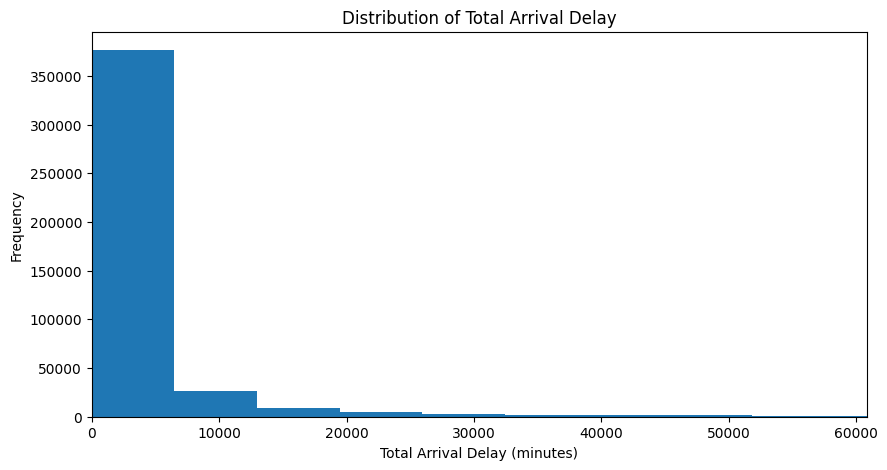

In [ ]:
# 11. Distribution of total arrival delay

plt.figure(figsize=(10, 5))
plt.hist(df["arr_delay"].dropna(), bins=100)
plt.xlabel("Total Arrival Delay (minutes)")
plt.ylabel("Frequency")
plt.title("Distribution of Total Arrival Delay")
plt.xlim(df["arr_delay"].quantile(0.00), df["arr_delay"].quantile(0.99))
plt.show()


,month,mean,median,count
0,1,4150.737127,1182.0,36394
1,2,3796.621447,1087.0,35921
2,3,4242.527948,1133.0,36157
3,4,3816.611604,983.0,35850
4,5,4318.864540,1129.0,35649
5,6,5561.630568,1575.0,37555
6,7,5901.046723,1710.0,35229
7,8,4889.800636,1397.0,35538
8,9,3016.667665,817.0,35404
9,10,3361.074557,907.0,35007


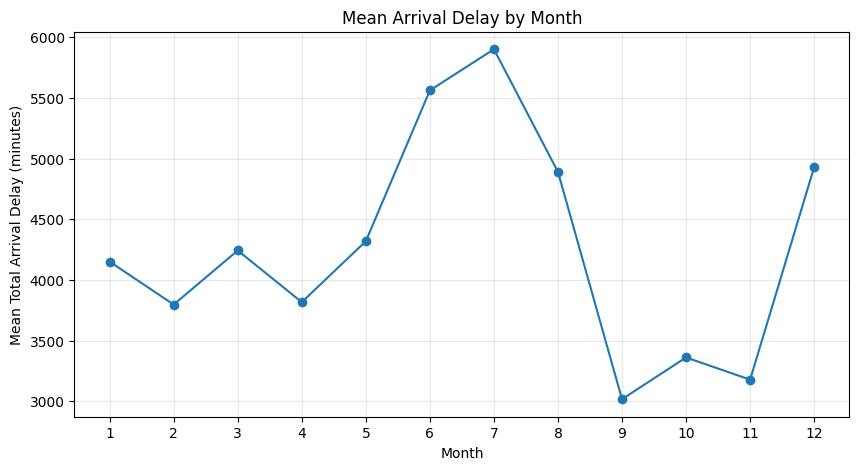

In [ ]:
# 12. Arrival delay by month

monthly_delay = (
    df.groupby("month")["arr_delay"]
      .agg(["mean", "median", "count"])
      .reset_index()
)

display(monthly_delay)

plt.figure(figsize=(10, 5))
plt.plot(monthly_delay["month"], monthly_delay["mean"], marker="o")
plt.xlabel("Month")
plt.ylabel("Mean Total Arrival Delay (minutes)")
plt.title("Mean Arrival Delay by Month")
plt.xticks(range(1, 13))
plt.grid(alpha=0.3)
plt.show()


,year,mean,median,count
0,2003,3715.403905,1298.0,8757
1,2004,4379.431062,1531.0,16689
2,2005,4498.442844,1502.0,17006
3,2006,4827.097719,1648.0,18062
4,2007,5181.715781,1710.0,19485
5,2008,4583.535763,1416.5,18902
6,2009,3741.190217,1199.0,17643
7,2010,3602.158078,1099.0,17561
8,2011,3960.694965,1229.0,15572
9,2012,3961.902548,1101.0,14366


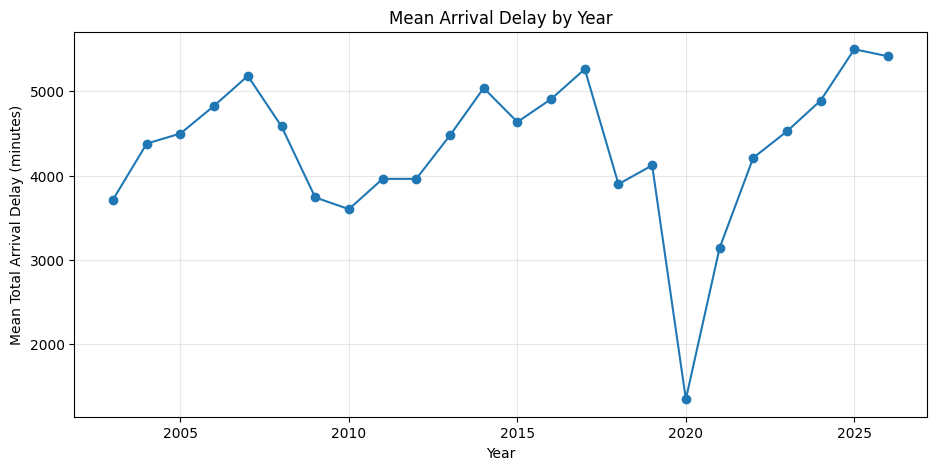

In [ ]:
# 13. Arrival delay by year

yearly_delay = (
    df.groupby("year")["arr_delay"]
      .agg(["mean", "median", "count"])
      .reset_index()
)

display(yearly_delay)

plt.figure(figsize=(11, 5))
plt.plot(yearly_delay["year"], yearly_delay["mean"], marker="o")
plt.xlabel("Year")
plt.ylabel("Mean Total Arrival Delay (minutes)")
plt.title("Mean Arrival Delay by Year")
plt.grid(alpha=0.3)
plt.show()


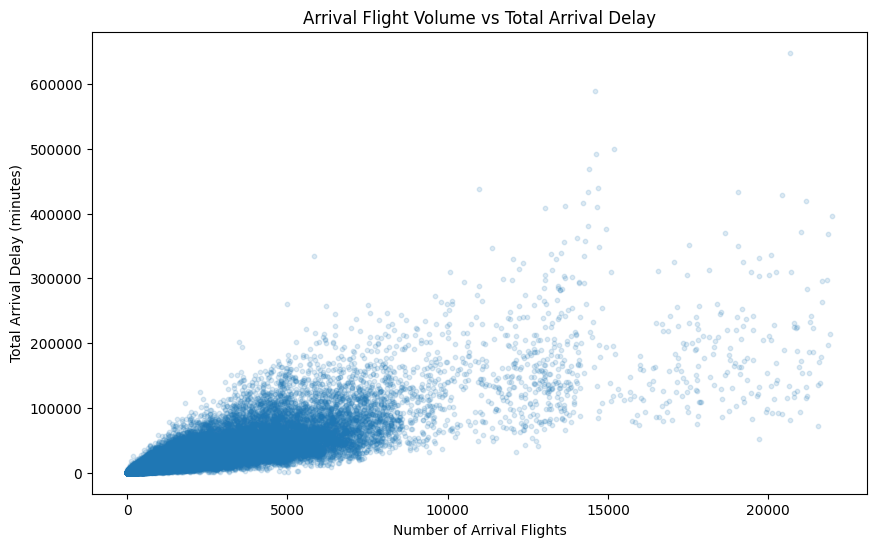

Correlation: 0.8741213010207505


In [ ]:
# 14. Relationship between number of arrival flights and total arrival delay

plot_df = df[["arr_flights", "arr_delay"]].dropna()

plt.figure(figsize=(10, 6))
plt.scatter(
    plot_df["arr_flights"],
    plot_df["arr_delay"],
    alpha=0.15,
    s=10
)
plt.xlabel("Number of Arrival Flights")
plt.ylabel("Total Arrival Delay (minutes)")
plt.title("Arrival Flight Volume vs Total Arrival Delay")
plt.show()

print("Correlation:", plot_df["arr_flights"].corr(plot_df["arr_delay"]))


In [ ]:
# 15. Top carriers by mean total arrival delay

carrier_summary = (
    df.groupby(["carrier", "carrier_name"])["arr_delay"]
      .agg(["mean", "median", "count"])
      .sort_values("mean", ascending=False)
)

display(carrier_summary.head(15))


mean  median  count
carrier carrier_name                                             
WN      Southwest Airlines Co.        12025.661509  6737.0  12668
        Southwest Airlines            11057.878404  4427.0  10099
AA      American Airlines Network     10810.467916  2944.5  11314
        American Airlines Inc.         8082.757534  2544.0  14435
UA      United Air Lines Network       6694.702655  1595.5  10846
        United Air Lines Inc.          6155.529214  1647.5  13966
DL      Delta Air Lines Network        5833.849731  1243.0  13915
B6      JetBlue Airways                5788.338777  1848.0  14697
NK      Spirit Air Lines               5058.168656  3201.0   1257
        Spirit Airlines                4854.658195  1837.0   5351
DL      Delta Air Lines Inc.           4621.645554  1219.0  20556
US      US Airways Inc.                4517.774712  1429.0  10693
CO      Continental Air Lines Inc.     4342.163265  1261.0   6909
EV      ExpressJet Airlines Inc.       4229.142520  1481.0  13135
MQ      American Eagle Airlines Inc.   4182.368281  1552.0  15404

In [ ]:
# 16. Top airports by mean total arrival delay
# Only include airport groups with at least 100 observations to reduce instability.

airport_summary = (
    df.groupby(["airport", "airport_name"])["arr_delay"]
      .agg(["mean", "median", "count"])
      .query("count >= 100")
      .sort_values("mean", ascending=False)
)

display(airport_summary.head(15))


,,mean,median,count
airport,airport_name,,,
ORD,"Chicago, IL: Chicago O'Hare International",31954.803018,9899.0,3711
ATL,"Atlanta, GA: Hartsfield-Jackson Atlanta International",27387.840000,5305.0,3675
DFW,"Dallas/Fort Worth, TX: Dallas/Fort Worth International",24264.300965,3591.0,3522
SFB,"Sanford, FL: Orlando Sanford International",19495.049020,17390.5,102
DEN,"Denver, CO: Denver International",17964.784230,4875.0,3513
EWR,"Newark, NJ: Newark Liberty International",17683.707547,6075.0,3392
LAS,"Las Vegas, NV: Harry Reid International",17122.508403,10104.5,714
SFO,"San Francisco, CA: San Francisco International",16461.590295,6667.0,3256
JFK,"New York, NY: John F. Kennedy International",16001.334676,6440.0,2483


## 4. Data Cleaning and Feature Selection

The main model uses only variables that are not direct components of the target.

The descriptive columns `carrier_name` and `airport_name` are excluded because `carrier` and `airport` already uniquely identify the corresponding airline and airport categories.

The delay-cause variables are excluded to prevent target leakage.


In [ ]:
# 17. Select modelling variables

features = [
    "year",
    "month",
    "carrier",
    "airport",
    "arr_flights"
]

target = "arr_delay"

model_df = df[features + [target]].copy()

# Remove rows where the target or selected predictors are missing.
model_df = model_df.dropna(subset=features + [target]).copy()

print("Original rows:", len(df))
print("Rows used for modelling:", len(model_df))
print("Rows removed:", len(df) - len(model_df))

display(model_df.head())


Original rows: 430151
Rows used for modelling: 429486
Rows removed: 665


,year,month,carrier,airport,arr_flights,arr_delay
0,2026,6,MQ,MLI,173.0,1818.0
1,2026,6,MQ,MLU,89.0,1267.0
2,2026,6,MQ,MOB,25.0,415.0
3,2026,6,MQ,MQT,60.0,665.0
4,2026,6,MQ,MRY,30.0,102.0


In [ ]:
# 18. Confirm that excluded delay-cause variables should not be used

delay_components = [
    "carrier_delay",
    "weather_delay",
    "nas_delay",
    "security_delay",
    "late_aircraft_delay"
]

component_sum = df[delay_components].sum(axis=1)

comparison = pd.DataFrame({
    "arr_delay": df["arr_delay"],
    "sum_of_delay_components": component_sum,
    "difference": df["arr_delay"] - component_sum
})

display(comparison.head(10))

print(
    "Proportion of non-missing observations where arr_delay equals "
    "the sum of the five delay-cause variables:",
    (comparison["difference"].dropna() == 0).mean()
)


,arr_delay,sum_of_delay_components,difference
0,1818.0,1818.0,0.0
1,1267.0,1267.0,0.0
2,415.0,415.0,0.0
3,665.0,665.0,0.0
4,102.0,102.0,0.0
5,1569.0,1569.0,0.0
6,425.0,425.0,0.0
7,614.0,614.0,0.0
8,476.0,476.0,0.0
9,50.0,50.0,0.0


Proportion of non-missing observations where arr_delay equals the sum of the five delay-cause variables: 0.9998114024671352


## 5. Train-Test Split

An 80/20 random split is used for the main model comparison. Because the dataset contains observations across many years and airline-airport combinations, the split allows the models to be evaluated on observations not used during training.


In [ ]:
# 19. Define X and y and split the data

X = model_df[features]
y = model_df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training observations:", X_train.shape[0])
print("Testing observations:", X_test.shape[0])


Training observations: 343588
Testing observations: 85898


In [ ]:
# 20. Preprocessing pipeline

categorical_features = ["carrier", "airport"]
numeric_features = ["year", "month", "arr_flights"]

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("Preprocessing pipeline created.")


Preprocessing pipeline created.


## 6. Regression Models

Five regression algorithms are compared:

- Linear Regression: baseline linear relationship.
- Ridge Regression: linear model with L2 regularisation.
- Decision Tree Regression: captures non-linear relationships and interactions.
- Random Forest Regression: combines multiple decision trees to improve generalisation.
- Gradient Boosting Regression: sequentially builds trees to reduce prediction errors.


In [ ]:
# 21. Define regression models

models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=10.0),
    "Decision Tree": DecisionTreeRegressor(
        max_depth=20,
        min_samples_leaf=10,
        random_state=42
    ),
    "Random Forest": RandomForestRegressor(
        n_estimators=100,
        max_depth=20,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=100,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    )
}

pipelines = {
    name: Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    for name, model in models.items()
}

print("Models ready:", list(pipelines.keys()))


Models ready: ['Linear Regression', 'Ridge Regression', 'Decision Tree', 'Random Forest', 'Gradient Boosting']


In [ ]:
# 22. Train and evaluate all models

results = []
predictions = {}

for name, pipeline in pipelines.items():
    print(f"Training {name}...")

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

    predictions[name] = y_pred

results_df = (
    pd.DataFrame(results)
      .sort_values("RMSE")
      .reset_index(drop=True)
)

display(results_df)


Training Linear Regression...
Training Ridge Regression...
Training Decision Tree...
Training Random Forest...
Training Gradient Boosting...


,Model,MAE,RMSE,R2
0,Random Forest,1239.559373,4158.182601,0.897799
1,Decision Tree,1370.176354,4742.419440,0.867062
2,Gradient Boosting,1688.215304,5210.745044,0.839510
3,Ridge Regression,2060.744129,6114.855258,0.778985
4,Linear Regression,2062.018484,6114.911018,0.778981


## 7. Model Evaluation

### Metric interpretation

**MAE** measures the average absolute prediction error in minutes.

**RMSE** also measures prediction error in minutes, but penalises large errors more strongly than MAE.

**R²** measures the proportion of variation in the target that is explained by the model. Values closer to 1 indicate greater explanatory power, while values near 0 indicate limited explanatory power.

The metrics should be considered together rather than relying on a single measure.


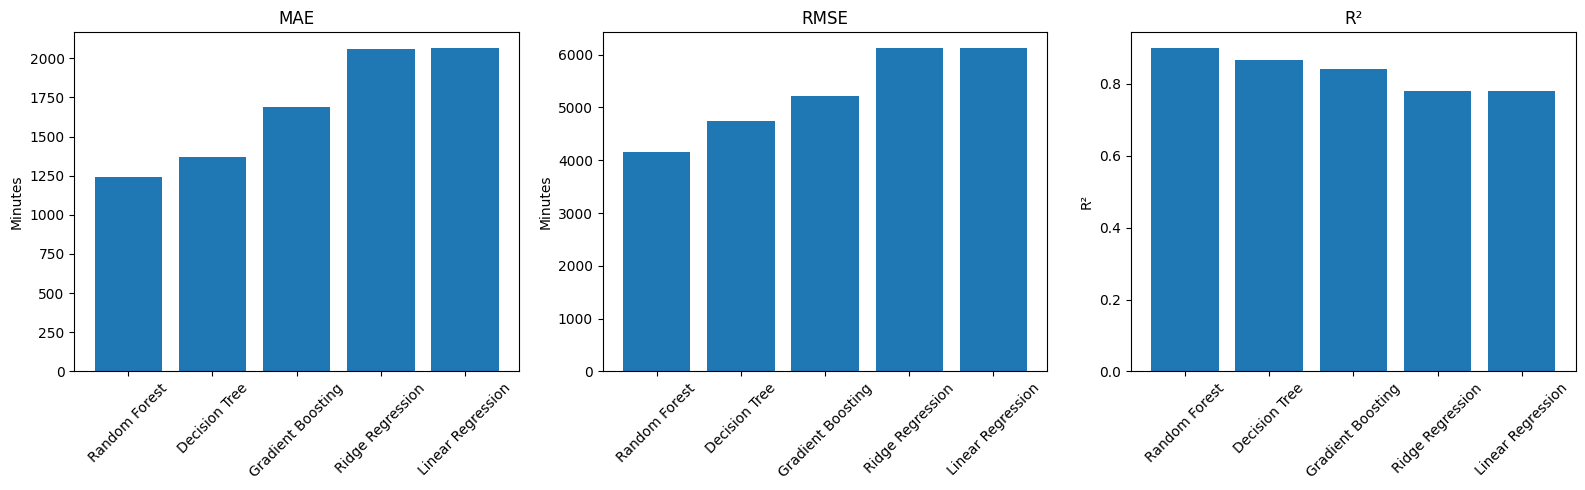

In [ ]:
# 23. Compare model performance visually

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].bar(results_df["Model"], results_df["MAE"])
axes[0].set_title("MAE")
axes[0].set_ylabel("Minutes")
axes[0].tick_params(axis="x", rotation=45)

axes[1].bar(results_df["Model"], results_df["RMSE"])
axes[1].set_title("RMSE")
axes[1].set_ylabel("Minutes")
axes[1].tick_params(axis="x", rotation=45)

axes[2].bar(results_df["Model"], results_df["R2"])
axes[2].set_title("R²")
axes[2].set_ylabel("R²")
axes[2].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()


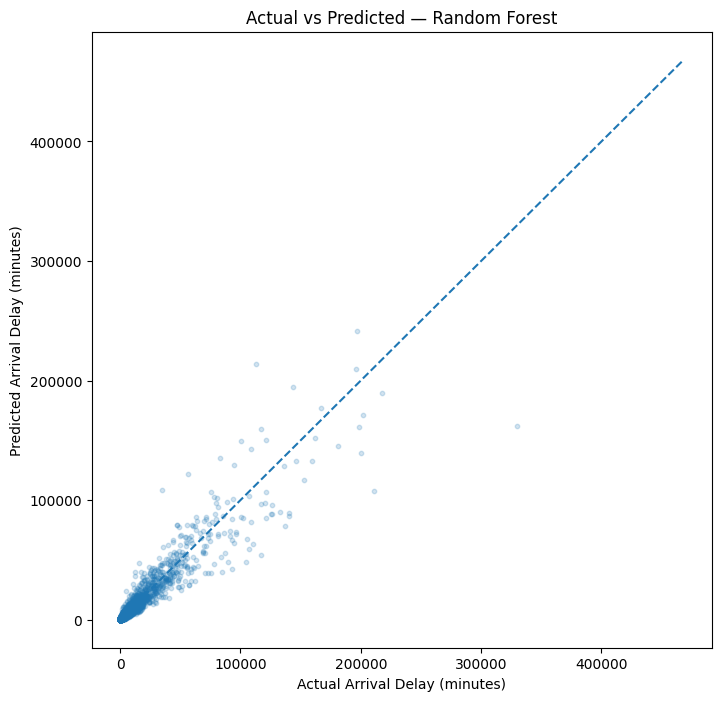

Model shown: Random Forest


In [ ]:
# 24. Actual vs predicted values for the best RMSE model

best_model_name = results_df.iloc[0]["Model"]
best_predictions = predictions[best_model_name]

sample_size = min(10000, len(y_test))
rng = np.random.default_rng(42)
sample_indices = rng.choice(len(y_test), size=sample_size, replace=False)

plt.figure(figsize=(8, 8))
plt.scatter(
    y_test.iloc[sample_indices],
    best_predictions[sample_indices],
    alpha=0.2,
    s=10
)

min_value = min(y_test.min(), best_predictions.min())
max_value = max(y_test.max(), best_predictions.max())

plt.plot([min_value, max_value], [min_value, max_value], linestyle="--")
plt.xlabel("Actual Arrival Delay (minutes)")
plt.ylabel("Predicted Arrival Delay (minutes)")
plt.title(f"Actual vs Predicted — {best_model_name}")
plt.show()

print("Model shown:", best_model_name)


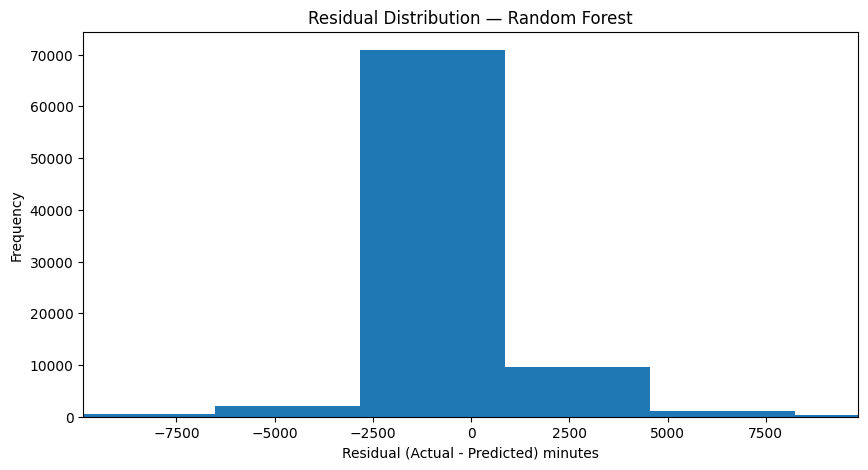

Mean residual: -11.750310884276882
Median residual: -73.59452884211927


In [ ]:
# 25. Residual analysis

residuals = y_test.values - best_predictions

plt.figure(figsize=(10, 5))
plt.hist(residuals, bins=100)
plt.xlabel("Residual (Actual - Predicted) minutes")
plt.ylabel("Frequency")
plt.title(f"Residual Distribution — {best_model_name}")
plt.xlim(
    np.quantile(residuals, 0.01),
    np.quantile(residuals, 0.99)
)
plt.show()

print("Mean residual:", round(residuals.mean(),2))
print("Median residual:", round(np.median(residuals),2))


,Feature,Importance
2,num__arr_flights,0.852384
0,num__year,0.042970
1,num__month,0.037630
331,cat__airport_ORD,0.013704
171,cat__airport_EWR,0.008953
9,cat__carrier_B6,0.004903
5,cat__carrier_AA,0.003765
36,cat__carrier_WN,0.003691
402,cat__airport_SFO,0.003310
146,cat__airport_DFW,0.002784


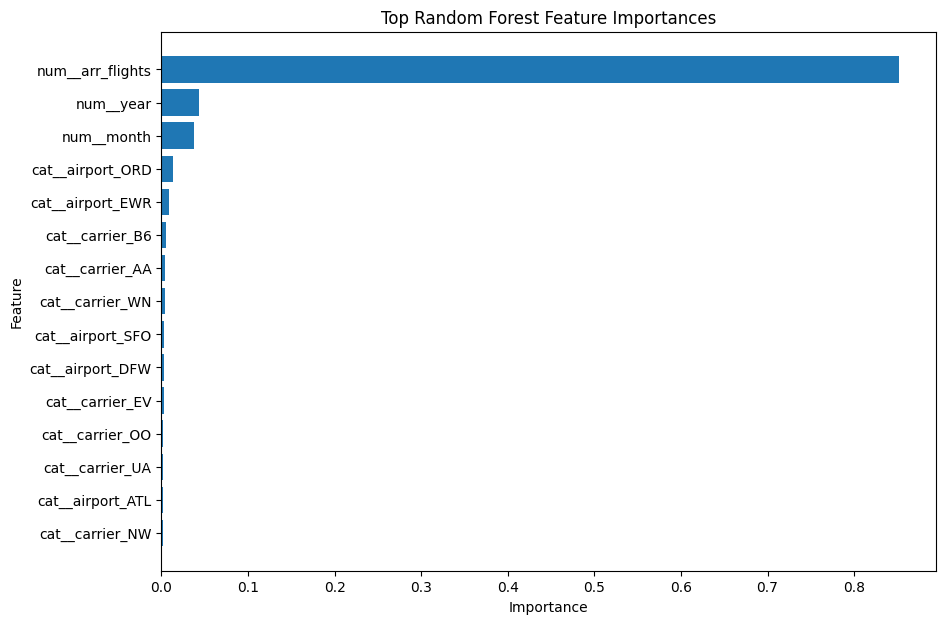

In [ ]:
# 26. Feature importance for tree-based models

# Use the Random Forest pipeline for interpretable feature importance.
rf_pipeline = pipelines["Random Forest"]

rf_preprocessor = rf_pipeline.named_steps["preprocessor"]
rf_model = rf_pipeline.named_steps["model"]

feature_names = rf_preprocessor.get_feature_names_out()
importances = rf_model.feature_importances_

importance_df = (
    pd.DataFrame({
        "Feature": feature_names,
        "Importance": importances
    })
    .sort_values("Importance", ascending=False)
)

display(importance_df.head(20))

plt.figure(figsize=(10, 7))
top_n = 15
plot_importance = importance_df.head(top_n).sort_values("Importance")

plt.barh(plot_importance["Feature"], plot_importance["Importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top Random Forest Feature Importances")
plt.show()


## 8. Optional Alternative Target: Average Arrival Delay per Flight

Because `arr_delay` is a total number of delay minutes, observations with many flights can naturally have larger totals.

As an additional analysis, an alternative continuous target can be created:

**average arrival delay per flight = `arr_delay / arr_flights`**

This alternative target answers a different question:

> **Can the characteristics of an airline-airport-month observation be used to predict the average arrival delay per arriving flight?**

This should be treated as an optional extension rather than replacing the main target unless the assignment specifically prefers a rate or per-flight measure.


In [ ]:
# 27. Optional: create average arrival delay per flight

optional_df = df[["year", "month", "carrier", "airport", "arr_flights", "arr_delay"]].copy()

optional_df["avg_arrival_delay"] = (
    optional_df["arr_delay"] / optional_df["arr_flights"]
)

optional_df = optional_df.replace([np.inf, -np.inf], np.nan).dropna(
    subset=["avg_arrival_delay"]
)

display(optional_df["avg_arrival_delay"].describe())


count    429486.000000
mean         12.068153
std          13.607903
min           0.000000
25%           5.863636
50%          10.004031
75%          15.682732
max        3174.000000
Name: avg_arrival_delay, dtype: float64

## 9. Conclusions

Use the model results generated above to write the final conclusion.

A suitable structure is:

1. State which regression models were compared.
2. Report the MAE, RMSE, and R² for each model.
3. Identify which model produced the lowest RMSE and compare its other metrics without treating the result as an absolute judgement outside the chosen evaluation criteria.
4. Discuss whether the predictive performance is useful for the project's stated research question.
5. Discuss important features identified by the tree-based model.
6. Explain limitations, including the aggregated nature of the dataset, potential temporal effects, and the fact that the dataset represents airline-airport-month observations rather than individual flights.

### Important limitation

The dataset is aggregated. Therefore, this project should **not** claim that it predicts the delay of a specific individual flight. It predicts the total arrival-delay minutes associated with an airline-airport-month observation.

### Leakage limitation

The delay-cause variables were deliberately excluded because they are direct components of the target. This makes the modelling task more meaningful and avoids giving the model information that effectively reveals the answer.


In [ ]:
# 28. Save model results

results_df.to_csv("regression_model_results.csv", index=False)

print("Saved: regression_model_results.csv")
display(results_df)


Saved: regression_model_results.csv


,Model,MAE,RMSE,R2
0,Random Forest,1239.559373,4158.182601,0.897799
1,Decision Tree,1370.176354,4742.419440,0.867062
2,Gradient Boosting,1688.215304,5210.745044,0.839510
3,Ridge Regression,2060.744129,6114.855258,0.778985
4,Linear Regression,2062.018484,6114.911018,0.778981
